In [3]:
# --- Imports/paths ---
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib import ticker

# --- Global style (Arial, bold titles, no grids, despine) ---
plt.rcParams.update({
    "font.family": "Arial",
    "axes.titleweight": "bold",
    "axes.grid": False,       # no major/minor grids
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# --- Paths ---
NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
OUT_DIR  = PROJECT_ROOT / "out"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook dir :", NB_DIR)
print("Project root :", PROJECT_ROOT)
print("DATA_DIR ok  :", DATA_DIR.exists())
print("OUT_DIR ok   :", OUT_DIR.exists())

# --- Local package imports (after SRC_DIR added) ---
from kin_tools.io import load_app_times, load_rem_times, load_ratings
from kin_tools.utils import sec_to_mmss, sec_to_mmss_signed, mmss_to_seconds
from kin_tools.stats import (
    lme_learning_random_intercept_app,
    lme_learning_random_intercept_rem,
    lme_learning_summary_app,
    lme_learning_summary_rem,
    lme_intercepts_table_app,
    lme_intercepts_table_rem,
    paired_test_collapsed,
    paired_test_collapsed_summary,
    ratings_paired_tests_per_metric,
)
from kin_tools.palettes import participant_color_map, app_marker_map

# --- Load tidy data ---
df_app = load_app_times(DATA_DIR / "app_times.csv")
df_rem = load_rem_times(DATA_DIR / "rem_times.csv")
df_rate = load_ratings(DATA_DIR / "ratings.csv")

participants = sorted(df_app["participant"].unique())
part_colors  = participant_color_map(participants)
app_markers  = app_marker_map([1,2,3])  # APP/REM markers are the same shapes

display(df_app.head(), df_rem.head(), df_rate.head())


Notebook dir : /Users/hannas/Desktop/SNEL/kinematics/Strain-Sensor-/user_comfort/notebooks
Project root : /Users/hannas/Desktop/SNEL/kinematics/Strain-Sensor-/user_comfort
DATA_DIR ok  : True
OUT_DIR ok   : True


,participant,method,app_label,app_index,time_str,time_sec
0,KIN3,DT,APP1,1,8:00,480
1,KIN4,DT,APP1,1,10:38,638
2,KIN5,DT,APP1,1,8:44,524
3,KIN7,DT,APP1,1,7:24,444
4,KIN3,DT,APP2,2,8:06,486


,participant,method,rem_label,rem_index,time_str,time_sec
0,KIN3,DT,REM1,1,7:58,478
1,KIN4,DT,REM1,1,8:57,537
2,KIN5,DT,REM1,1,5:16,316
3,KIN7,DT,REM1,1,4:56,296
4,KIN3,DT,REM2,2,9:02,542


,participant,method,app_label,app_index,metric,rating
0,KIN3,DT,APP1,1,ease,7.0
1,KIN4,DT,APP1,1,ease,10.0
2,KIN5,DT,APP1,1,ease,6.0
3,KIN7,DT,APP1,1,ease,7.0
4,KIN3,DT,APP2,2,ease,6.0


In [4]:
# APP/REM/survey stats printed for Figure 5 panels B-F
# LME slope CIs are Wald 95% CIs from statsmodels MixedLM.
# LME R2 point values are Nakagawa-style marginal/conditional R2 without bootstrap.
# R2 CIs are also shown using participant-cluster bootstraps.
# Paired-test effect sizes are paired Cohen's dz and its small-sample corrected Hedges' g.
LME_BOOTSTRAPS = 100

def _fmt_ci(lo, hi, digits=2):
    return f"[{lo:.{digits}f}, {hi:.{digits}f}]"

def _fmt_p(p):
    return "<0.0001" if p < 1e-4 else f"{p:.4f}"

def print_lme_summary(label, summary, unit):
    n_boot = summary.get("n_boot_success", 0)
    print(
        f"{label}: slope={summary['slope']:.2f} {unit}, "
        f"95% CI={_fmt_ci(summary['slope_ci_low'], summary['slope_ci_high'])}, "
        f"t={summary['t_value']:.3f}, p={_fmt_p(summary['p_value'])}"
    )
    print(
        f"    R2 marginal (no bootstrap)={summary['r2_marginal']:.3f}; "
        f"bootstrap 95% CI={_fmt_ci(summary['r2_marginal_boot_ci_low'], summary['r2_marginal_boot_ci_high'], digits=3)}"
    )
    print(
        f"    R2 conditional (no bootstrap)={summary['r2_conditional']:.3f}; "
        f"bootstrap 95% CI={_fmt_ci(summary['r2_conditional_boot_ci_low'], summary['r2_conditional_boot_ci_high'], digits=3)} "
        f"(bootstrap n={n_boot})"
    )

def print_paired_summary(label, summary, unit=""):
    unit_txt = f" {unit}" if unit else ""
    mmss_txt = f" ({sec_to_mmss_signed(summary['mean_diff'])})" if unit == "s" else ""
    print(
        f"{label}: Δ={summary['mean_diff']:.2f}{unit_txt}{mmss_txt}, "
        f"95% CI={_fmt_ci(summary['ci_low'], summary['ci_high'])}{unit_txt}, "
        f"t={summary['t_value']:.3f}, p={_fmt_p(summary['p_value'])}, "
        f"Cohen's dz={summary['cohen_dz']:.3f}, Hedges' g={summary['hedges_g']:.3f}, "
        f"n_pairs={summary['n_pairs']}"
    )

# B Application learning models
print("B) Application LME learning models")
app_dt_summary, fit_dt = lme_learning_summary_app(
    df_app, "DT", recode_app1_to_zero=True, n_boot=LME_BOOTSTRAPS, seed=5001
)
app_tt_summary, fit_tt = lme_learning_summary_app(
    df_app, "TT", recode_app1_to_zero=True, n_boot=LME_BOOTSTRAPS, seed=5002
)
slope_dt = app_dt_summary["slope"]
p_dt = app_dt_summary["p_value"]
t_dt_app = app_dt_summary["t_value"]
slope_tt = app_tt_summary["slope"]
p_tt = app_tt_summary["p_value"]
t_tt_app = app_tt_summary["t_value"]
print_lme_summary("APP LME DT", app_dt_summary, "s/app")
print_lme_summary("APP LME TT", app_tt_summary, "s/app")

# C Application method comparison
print("\nC) Collapsed application paired t-test")
app_pair_summary = paired_test_collapsed_summary(df_app, which="app")
mean_diff = app_pair_summary["mean_diff"]
tval_app = app_pair_summary["t_value"]
pval_app = app_pair_summary["p_value"]
print_paired_summary("APP collapsed TT-DT", app_pair_summary, unit="s")

# D Removal learning models
print("\nD) Removal LME learning models")
rem_dt_summary, fit_dt_r = lme_learning_summary_rem(
    df_rem, "DT", recode_rem1_to_zero=True, n_boot=LME_BOOTSTRAPS, seed=5003
)
rem_tt_summary, fit_tt_r = lme_learning_summary_rem(
    df_rem, "TT", recode_rem1_to_zero=True, n_boot=LME_BOOTSTRAPS, seed=5004
)
slope_dt_r = rem_dt_summary["slope"]
p_dt_r = rem_dt_summary["p_value"]
t_dt_rem = rem_dt_summary["t_value"]
slope_tt_r = rem_tt_summary["slope"]
p_tt_r = rem_tt_summary["p_value"]
t_tt_rem = rem_tt_summary["t_value"]
print_lme_summary("REM LME DT", rem_dt_summary, "s/rem")
print_lme_summary("REM LME TT", rem_tt_summary, "s/rem")

# E Removal method comparison
print("\nE) Collapsed removal paired t-test")
rem_pair_summary = paired_test_collapsed_summary(df_rem, which="rem")
mean_diff_r = rem_pair_summary["mean_diff"]
tval_rem = rem_pair_summary["t_value"]
pval_rem = rem_pair_summary["p_value"]
print_paired_summary("REM collapsed TT-DT", rem_pair_summary, unit="s")

# F Survey ratings
print("\nF) Survey ratings paired t-tests")
stats_df = ratings_paired_tests_per_metric(df_rate)
for met in ["ease", "stability", "adhesion"]:
    row = stats_df[stats_df.metric == met].iloc[0]
    print_paired_summary(f"{met} TT-DT", row.to_dict(), unit="rating points")


B) Application LME learning models
APP LME DT: slope=-39.50 s/app, 95% CI=[-74.22, -4.78], t=-2.230, p=0.0258
    R2 marginal (no bootstrap)=0.092; bootstrap 95% CI=[0.038, 0.902]
    R2 conditional (no bootstrap)=0.796; bootstrap 95% CI=[0.108, 0.971] (bootstrap n=100)
APP LME TT: slope=-60.75 s/app, 95% CI=[-99.54, -21.96], t=-3.070, p=0.0021
    R2 marginal (no bootstrap)=0.143; bootstrap 95% CI=[0.057, 0.624]
    R2 conditional (no bootstrap)=0.833; bootstrap 95% CI=[0.279, 0.912] (bootstrap n=100)

C) Collapsed application paired t-test
APP collapsed TT-DT: Δ=-130.58 s (-2:11), 95% CI=[-180.06, -81.11] s, t=-5.810, p=0.0001, Cohen's dz=-1.677, Hedges' g=-1.560, n_pairs=12

D) Removal LME learning models
REM LME DT: slope=-26.25 s/rem, 95% CI=[-60.48, 7.98], t=-1.503, p=0.1328
    R2 marginal (no bootstrap)=0.036; bootstrap 95% CI=[0.012, 0.370]
    R2 conditional (no bootstrap)=0.824; bootstrap 95% CI=[0.170, 0.967] (bootstrap n=100)
REM LME TT: slope=-44.38 s/rem, 95% CI=[-87.23,

In [5]:
def shared_ylim_seconds(df, margin=0.22):
    """Return (0, top) in seconds with a uniform headroom margin."""
    top = float(df["time_sec"].max()) * (1.0 + margin)
    return 0.0, top

def p_to_stars(p):
    # ok thresholds?
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "ns"

def annotate_sig_bracket(ax, x1, x2, y, p, text=None, lw=2.0, fs=14):
    ax.plot([x1, x2], [y, y], color="black", lw=lw, solid_capstyle="round")
    label = text if text is not None else p_to_stars(p)
    ax.text((x1+x2)/2, y, label, ha="center", va="bottom", fontsize=fs)

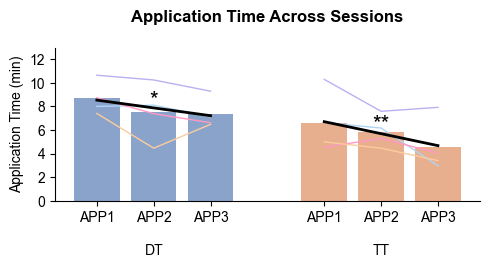

In [6]:
# B Application times: DT vs TT, split by method
def plot_app_split_by_method(df_app, save_path=None, ax=None):
    idxs = [1,2,3]
    participants = sorted(df_app["participant"].unique())
    part_colors = participant_color_map(participants)

    color_DT = "#4C72B0"
    color_TT = "#DD8452"

    dt_x = [0,1,2]
    tt_x = [4,5,6]

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(5,3))  # (B) size
    else:
        fig = ax.figure

    means_dt = [float(df_app[(df_app.method=="DT")&(df_app.app_index==i)].time_sec.mean()) for i in idxs]
    means_tt = [float(df_app[(df_app.method=="TT")&(df_app.app_index==i)].time_sec.mean()) for i in idxs]
    ax.bar(dt_x, means_dt, color=color_DT, alpha=0.65, width=0.8)
    ax.bar(tt_x, means_tt, color=color_TT, alpha=0.65, width=0.8)

    # Lines only (no visible markers)
    for p in participants:
        c = part_colors[p]
        y_dt, y_tt = [], []
        for i, x in zip(idxs, dt_x):
            v = df_app[(df_app.participant==p)&(df_app.method=="DT")&(df_app.app_index==i)].time_sec.iloc[0]
            y_dt.append(v)
        ax.plot(dt_x, y_dt, color=c, lw=1.0)

        for i, x in zip(idxs, tt_x):
            v = df_app[(df_app.participant==p)&(df_app.method=="TT")&(df_app.app_index==i)].time_sec.iloc[0]
            y_tt.append(v)
        ax.plot(tt_x, y_tt, color=c, lw=1.0)

    # LME learning stats (random intercept per method)
    slope_dt, p_dt, fit_dt = lme_learning_random_intercept_app(df_app, "DT", recode_app1_to_zero=True)
    slope_tt, p_tt, fit_tt = lme_learning_random_intercept_app(df_app, "TT", recode_app1_to_zero=True)

    # Slope lines using fixed intercept at APP1 (index0=0)
    b0_dt = float(fit_dt.params["Intercept"])
    b0_tt = float(fit_tt.params["Intercept"])
    yline_dt = [b0_dt + slope_dt*(i-1) for i in idxs]
    yline_tt = [b0_tt + slope_tt*(i-1) for i in idxs]
    ax.plot(dt_x, yline_dt, color="black", lw=2.0, alpha=1.0)
    ax.plot(tt_x, yline_tt, color="black", lw=2.0, alpha=1.0)

    # Axis formatting
    ax.set_xticks(dt_x + tt_x)
    ax.set_xticklabels([f"APP{i}" for i in idxs] + [f"APP{i}" for i in idxs], fontsize=10)
    ax.text(np.mean(dt_x), -0.28, "DT", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=10)
    ax.text(np.mean(tt_x), -0.28, "TT", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=10)

    # Uniform y-limits with panel (C)
    y0, ytop = shared_ylim_seconds(df_app, margin=0.22)
    ax.set_ylim(y0, ytop)

    # Y-axis ticks: whole minutes, every 2 minutes
    max_minute = int(np.ceil(ytop / 60.0))
    minute_ticks = np.arange(0, max_minute + 1, 2)
    yticks_sec = [m * 60 for m in minute_ticks if (m * 60) >= y0 and (m * 60) <= ytop]

    ax.yaxis.set_major_locator(ticker.FixedLocator(yticks_sec))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f"{int(round(y/60.0))}"))
    
    ax.set_ylabel("Application Time (min)")
    ax.set_title("Application Time Across Sessions\n", loc="center")

    # --- Significance stars above slope lines (instead of slope text) ---
    star_dt = p_to_stars(p_dt)
    star_tt = p_to_stars(p_tt)

    # place near the middle APP for each method, slightly above line
    y_range = ytop - y0 if ytop > y0 else 1.0
    if star_dt:
        x_star_dt = np.mean(dt_x)
        y_star_dt = max(yline_dt) - 0.06 * y_range
        ax.text(x_star_dt, y_star_dt, star_dt,
                ha="center", va="bottom", fontsize=16)

    if star_tt:
        x_star_tt = np.mean(tt_x)
        y_star_tt = max(yline_tt) - 0.08 * y_range
        ax.text(x_star_tt, y_star_tt, star_tt,
                ha="center", va="bottom", fontsize=16)

    if own_fig:
        fig.tight_layout()
        if save_path is None:
            save_path = OUT_DIR / "fig5B_app_split_by_method.svg"
        fig.savefig(save_path, format="svg")
        plt.show()


plot_app_split_by_method(df_app, OUT_DIR / "fig5B_app_split_by_method.svg")

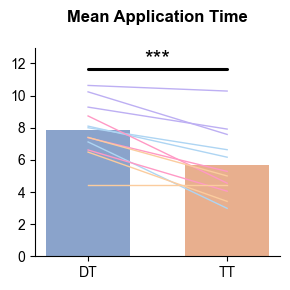

In [7]:
# C Collapsed application times: DT vs TT (+ paired t-test)
def plot_app_collapsed_with_stats(df_app, save_path=None, ax=None):
    participants = sorted(df_app["participant"].unique())
    part_colors = participant_color_map(participants)
    mark_map = app_marker_map([1,2,3])

    color_DT = "#4C72B0"
    color_TT = "#DD8452"

    collapsed = df_app.groupby("method")["time_sec"].mean()
    y_DT, y_TT = collapsed["DT"], collapsed["TT"]

    # Shared y-limits with panel (B)
    y0, ytop = shared_ylim_seconds(df_app, margin=0.22)

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(3,3))  # (C) size
    else:
        fig = ax.figure
        
    ax.bar([0,1], [y_DT, y_TT], color=[color_DT, color_TT], alpha=0.65, width=0.6)

    # Lines only (no visible markers), connect TT and DT per participant per APP
    for p in participants:
        for i in [1,2,3]:
            d = df_app[(df_app.participant==p)&(df_app.method=="DT")&(df_app.app_index==i)].time_sec.iloc[0]
            t = df_app[(df_app.participant==p)&(df_app.method=="TT")&(df_app.app_index==i)].time_sec.iloc[0]
            ax.plot([0,1], [d,t], color=part_colors[p], lw=1.0)

    mean_diff, tval, pval = paired_test_collapsed(df_app, which="app")

    # bracket position within shared ylim
    y_top = ytop * 0.9 # 0.87
    annotate_sig_bracket(ax, 0, 1, y_top, pval, lw=2.2, fs=16)

    ax.set_xticks([0,1]); ax.set_xticklabels(["DT","TT"])
    ax.set_title("Mean Application Time\n", loc="center")

    ax.set_ylim(y0, ytop)
    max_minute = int(np.ceil(ytop / 60.0))
    minute_ticks = np.arange(0, max_minute + 1, 2)
    yticks_sec = [m * 60 for m in minute_ticks if (m * 60) >= y0 and (m * 60) <= ytop]

    ax.yaxis.set_major_locator(ticker.FixedLocator(yticks_sec))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f"{int(round(y/60.0))}"))
    #ax.set_ylabel("Application Time (min)")

    if own_fig:
        fig.tight_layout()
        if save_path is None:
            save_path = OUT_DIR / "fig5C_app_collapsed.svg"
        fig.savefig(save_path, format="svg")
        plt.show()

plot_app_collapsed_with_stats(df_app)

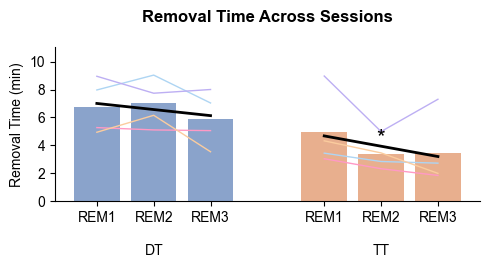

In [8]:
# D Removal times: DT vs TT, split by method")
def plot_rem_split_by_method(df_rem, save_path=None, ax=None):
    idxs = [1,2,3]
    participants = sorted(df_rem["participant"].unique())
    part_colors = participant_color_map(participants)
    color_DT = "#4C72B0"; color_TT = "#DD8452"

    dt_x = [0,1,2]; tt_x = [4,5,6]
    
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(5,3))  # (D) size
    else:
        fig = ax.figure

    means_dt = [float(df_rem[(df_rem.method=="DT")&(df_rem.rem_index==i)].time_sec.mean()) for i in idxs]
    means_tt = [float(df_rem[(df_rem.method=="TT")&(df_rem.rem_index==i)].time_sec.mean()) for i in idxs]
    ax.bar(dt_x, means_dt, color=color_DT, alpha=0.65, width=0.8)
    ax.bar(tt_x, means_tt, color=color_TT, alpha=0.65, width=0.8)

    # Lines only (no markers)
    for p in participants:
        c = part_colors[p]
        y_dt, y_tt = [], []
        for i, x in zip(idxs, dt_x):
            v = df_rem[(df_rem.participant==p)&(df_rem.method=="DT")&(df_rem.rem_index==i)].time_sec.iloc[0]
            # ax.scatter(x, v, color=c, s=0, alpha=0)
            y_dt.append(v)
        ax.plot(dt_x, y_dt, color=c, lw=1.0)

        for i, x in zip(idxs, tt_x):
            v = df_rem[(df_rem.participant==p)&(df_rem.method=="TT")&(df_rem.rem_index==i)].time_sec.iloc[0]
            # ax.scatter(x, v, color=c, s=0, alpha=0)
            y_tt.append(v)
        ax.plot(tt_x, y_tt, color=c, lw=1.0)

    # LME slope lines
    slope_dt, p_dt, fit_dt = lme_learning_random_intercept_rem(df_rem, "DT", recode_rem1_to_zero=True)
    slope_tt, p_tt, fit_tt = lme_learning_random_intercept_rem(df_rem, "TT", recode_rem1_to_zero=True)
    b0_dt = float(fit_dt.params["Intercept"])
    b0_tt = float(fit_tt.params["Intercept"])
    yline_dt = [b0_dt + slope_dt*(i-1) for i in idxs]
    yline_tt = [b0_tt + slope_tt*(i-1) for i in idxs]
    ax.plot(dt_x, yline_dt, color="black", lw=2.0, alpha=1.0)
    ax.plot(tt_x, yline_tt, color="black", lw=2.0, alpha=1.0)

    ax.set_xticks(dt_x + tt_x)
    ax.set_xticklabels([f"REM{i}" for i in idxs] + [f"REM{i}" for i in idxs], fontsize=10)
    ax.text(np.mean(dt_x), -0.28, "DT", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=10)
    ax.text(np.mean(tt_x), -0.28, "TT", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=10)

    # Uniform y-limits with panel (E)
    y0, ytop = shared_ylim_seconds(df_rem, margin=0.22)
    ax.set_ylim(y0, ytop)
    
    max_minute = int(np.ceil(ytop / 60.0))
    minute_ticks = np.arange(0, max_minute + 1, 2)
    yticks_sec = [m * 60 for m in minute_ticks if (m * 60) >= y0 and (m * 60) <= ytop]

    ax.yaxis.set_major_locator(ticker.FixedLocator(yticks_sec))
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda y, pos: f"{int(round(y/60.0))}")
    )
    ax.set_ylabel("Removal Time (min)")
    ax.set_title("Removal Time Across Sessions\n", loc="center")

    # Stats stars on slope lines (like panel B)
    # star_dt = p_to_stars(p_dt) # not significant
    star_tt = p_to_stars(p_tt)

    y_range = ytop - y0 if ytop > y0 else 1.0
    
    # dt not significant!!!
    # if star_dt:
    #     x_star_dt = np.mean(dt_x)
    #     y_star_dt = max(yline_dt) - 0.05 * y_range
    #     ax.text(x_star_dt, y_star_dt, star_dt,
    #             ha="center", va="bottom", fontsize=16)

    if star_tt:
        x_star_tt = np.mean(tt_x)
        y_star_tt = max(yline_tt) - 0.08 * y_range
        ax.text(x_star_tt, y_star_tt, star_tt,
                ha="center", va="bottom", fontsize=16)

    if own_fig:
        fig.tight_layout()
        if save_path is None:
            save_path = OUT_DIR / "fig5D_rem_split_by_method.svg"
        fig.savefig(save_path, format="svg")
        plt.show()

plot_rem_split_by_method(df_rem, OUT_DIR / "fig5D_rem_split_by_method.svg")


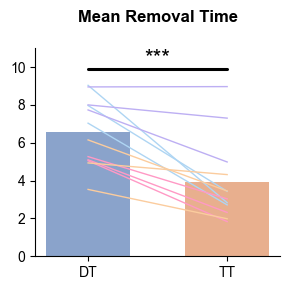

In [9]:
# E
def plot_rem_collapsed_with_stats(df_rem, save_path=None, ax=None):
    participants = sorted(df_rem["participant"].unique())
    part_colors = participant_color_map(participants)
    mark_map = app_marker_map([1,2,3])

    color_DT = "#4C72B0"; color_TT = "#DD8452"
    collapsed = df_rem.groupby("method")["time_sec"].mean()
    y_DT, y_TT = collapsed["DT"], collapsed["TT"]

    # Shared y-limits with (D)
    y0, ytop = shared_ylim_seconds(df_rem, margin=0.22)

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(3,3))  # (E) size
    else:
        fig = ax.figure

    ax.bar([0,1], [y_DT, y_TT], color=[color_DT, color_TT], alpha=0.65, width=0.6)

    # Lines only (no markers)
    for p in participants:
        for i in [1,2,3]:
            d = df_rem[(df_rem.participant==p)&(df_rem.method=="DT")&(df_rem.rem_index==i)].time_sec.iloc[0]
            t = df_rem[(df_rem.participant==p)&(df_rem.method=="TT")&(df_rem.rem_index==i)].time_sec.iloc[0]
            ax.plot([0,1],[d,t], color=part_colors[p], lw=1.0)

    mean_diff, tval, pval = paired_test_collapsed(df_rem, which="rem")
    y_top = ytop * 0.9 
    annotate_sig_bracket(ax, 0, 1, y_top, pval, lw=2.2, fs=16)

    ax.set_xticks([0,1]); ax.set_xticklabels(["DT","TT"])
    ax.set_title("Mean Removal Time\n", loc="center")

    ax.set_ylim(y0, ytop)
    max_minute = int(np.ceil(ytop / 60.0))
    minute_ticks = np.arange(0, max_minute + 1, 2)
    yticks_sec = [m * 60 for m in minute_ticks if (m * 60) >= y0 and (m * 60) <= ytop]

    ax.yaxis.set_major_locator(ticker.FixedLocator(yticks_sec))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f"{int(round(y/60.0))}"))

    #ax.set_ylabel("Removal Time (min)")

    if own_fig:
        fig.tight_layout()
        if save_path is None:
            save_path = OUT_DIR / "fig5E_rem_collapsed.svg"
        fig.savefig(save_path, format="svg")
        plt.show()

plot_rem_collapsed_with_stats(df_rem)


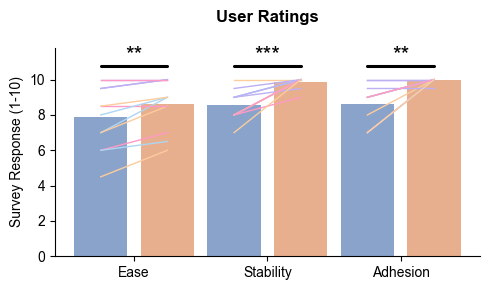

In [10]:
# F
def plot_ratings_subset_with_stats(df_rate, metrics=("ease","stability","adhesion"),  save_path=None, ax=None):
    d = df_rate[df_rate["metric"].isin(metrics)].copy()
    methods = ["DT","TT"]
    participants = sorted(d["participant"].unique())
    part_colors = participant_color_map(participants)
    mark_map = app_marker_map([1,2,3])
    color_DT, color_TT = "#4C72B0", "#DD8452"

    means = (d.groupby(["metric","method"], as_index=False)["rating"]
               .mean().rename(columns={"rating":"mean_rating"}))
    x_pairs = [(m, meth) for m in metrics for meth in methods]
    x = np.arange(len(x_pairs))

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(5,3))  # (F) size
    else:
        fig = ax.figure

    mean_map = {(r.metric, r.method): r.mean_rating for _, r in means.iterrows()}

    # bars
    for i, (met, meth) in enumerate(x_pairs):
        ax.bar(i, mean_map[(met, meth)],
               color=(color_DT if meth=="DT" else color_TT),
               alpha=0.65, width=0.8)

    # Lines only (no markers) connecting DT↔TT per participant per APP
    for mi, met in enumerate(metrics):
        x_dt = mi*2
        x_tt = mi*2 + 1
        for app_i in [1,2,3]:
            dt_vals = (d[(d.metric==met)&(d.method=="DT")&(d.app_index==app_i)]
                         .sort_values("participant")["rating"].to_numpy())
            tt_vals = (d[(d.metric==met)&(d.method=="TT")&(d.app_index==app_i)]
                         .sort_values("participant")["rating"].to_numpy())
            for p_idx, p in enumerate(participants):
                ax.plot([x_dt, x_tt], [dt_vals[p_idx], tt_vals[p_idx]], color=part_colors[p], lw=1.0)

    # paired tests per metric + headroom for brackets
    stats_df = ratings_paired_tests_per_metric(df_rate)
    stats_df = stats_df[stats_df["metric"].isin(metrics)]
    ax.set_ylim(0, 10.0)  # Ratings are 1–10; fixes vertical profile next to (G)
    ymax = max(ax.get_ylim())
    ax.set_ylim(0, ymax + 1.8)  # extra white space
    for mi, met in enumerate(metrics):
        x_dt, x_tt = mi*2, mi*2+1
        p = float(stats_df.loc[stats_df.metric==met, "p_value"].iloc[0])
        y = ymax + 0.8
        annotate_sig_bracket(ax, x_dt, x_tt, y, p, lw=2.2, fs=16)

    centers = [mi*2 + 0.5 for mi in range(len(metrics))]
    ax.set_xticks(centers)
    ax.set_xticklabels([m.capitalize() for m in metrics])
    ax.set_ylabel("Survey Response (1-10)")
    ax.set_title("User Ratings\n", loc="center")

    if own_fig:
        fig.tight_layout()
        if save_path is None:
            save_path = OUT_DIR / "fig5F_ratings_three_metrics.svg"
        fig.savefig(save_path, format="svg")
        plt.show()

plot_ratings_subset_with_stats(df_rate, metrics=("ease","stability","adhesion"))


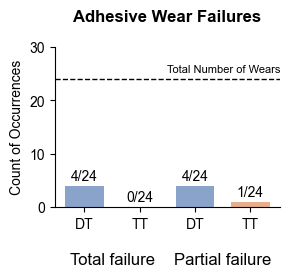

In [11]:
# G Failure summary
def plot_failure_summary_counts(
    total_fail_DT, total_fail_TT, partial_fail_DT, partial_fail_TT,
    N_DT=24, N_TT=24, save_path=None, ax=None
):
    color_DT = "#4C72B0"; color_TT = "#DD8452"
    labels_under_bars = ["DT", "TT", "DT", "TT"]  # row 1 (right under each bar)
    vals   = [total_fail_DT, total_fail_TT, partial_fail_DT, partial_fail_TT]
    cols   = [color_DT, color_TT, color_DT, color_TT]
    denoms = [N_DT, N_TT, N_DT, N_TT]

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(3,3))
    else:
        fig = ax.figure

    xs = np.arange(4)
    ax.bar(xs, vals, color=cols, alpha=0.65, width=0.7)
    for x, v, d in zip(xs, vals, denoms):
        ax.text(x, v + 0.5, f"{v}/{d}", ha="center", va="bottom", fontsize=10)

    # dashed line + label for total wears
    total_wears = max(denoms)
    ax.axhline(total_wears, linestyle="--", linewidth=1, color="k")

    # label centered over all four bars
    x_center = (xs[0] + xs[-1]) / 2.0
    ax.text(
        x_center,
        total_wears + 0.8,
        "Total Number of Wears",
        ha="left",
        va="bottom",
        fontsize=8
    )

    ax.set_xticks(xs)
    ax.set_xticklabels(labels_under_bars, fontsize=10)

    pair_centers = [(0+1)/2, (2+3)/2]
    group_labels = ["Total failure", "Partial failure"]

    fig.subplots_adjust(bottom=0.20)
    for xc, glab in zip(pair_centers, group_labels):
        ax.text(xc, -0.28, glab, ha="center", va="top",
                transform=ax.get_xaxis_transform(), fontsize=12)

    ax.set_ylim(0, 30)
    ax.set_ylabel("Count of Occurrences")
    ax.set_title("Adhesive Wear Failures\n", loc="center")

    if own_fig:
        fig.tight_layout()
        if save_path is None:
            save_path = OUT_DIR / "fig5G_failure_summary_counts.svg"
        fig.savefig(save_path, format="svg")
        plt.show()

# manually adding counts here 
plot_failure_summary_counts(
    total_fail_DT=4, total_fail_TT=0,
    partial_fail_DT=4, partial_fail_TT=1,
    N_DT=24, N_TT=24
)


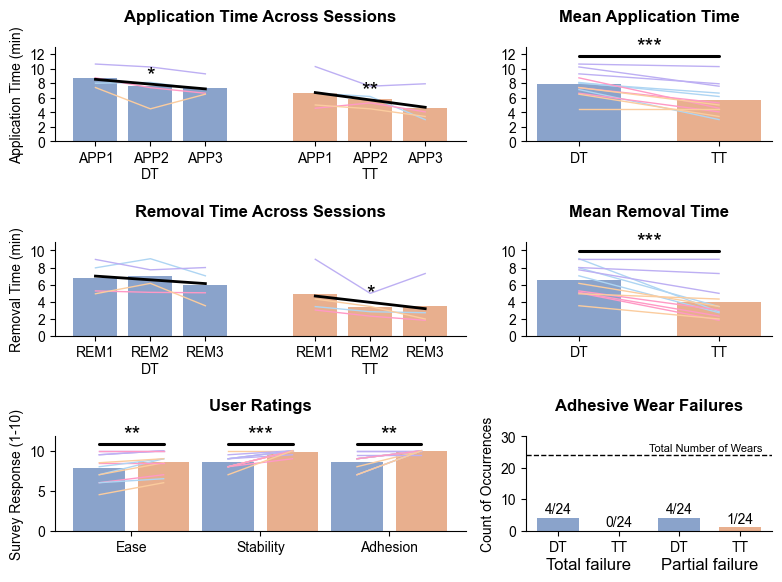

In [12]:
# mega plot B-G
def plot_all_panels_3x2(df_app, df_rem, df_rate,
                        total_fail_DT, total_fail_TT,
                        partial_fail_DT, partial_fail_TT,
                        N_DT=24, N_TT=24,
                        save_path=None):

    fig, axs = plt.subplots(
        3, 2,
        figsize=(8, 6),
        gridspec_kw={
            "width_ratios": [5, 3],  # left column wide, right column narrower
            #"hspace": 0.3                # more space between rows ?
        }
    )

    # Row 0
    plot_app_split_by_method(df_app, ax=axs[0,0])
    plot_app_collapsed_with_stats(df_app, ax=axs[0,1])

    # Row 1
    plot_rem_split_by_method(df_rem, ax=axs[1,0])
    plot_rem_collapsed_with_stats(df_rem, ax=axs[1,1])

    # Row 2
    plot_ratings_subset_with_stats(df_rate,
                                   metrics=("ease","stability","adhesion"),
                                   ax=axs[2,0])
    plot_failure_summary_counts(
        total_fail_DT=total_fail_DT,
        total_fail_TT=total_fail_TT,
        partial_fail_DT=partial_fail_DT,
        partial_fail_TT=partial_fail_TT,
        N_DT=N_DT, N_TT=N_TT,
        ax=axs[2,1]
    )

    fig.tight_layout()

    if save_path is None:
        save_path = OUT_DIR / "fig5_all_panels_3x2.svg"
    fig.savefig(save_path, format="svg")
    plt.show()


plot_all_panels_3x2(
    df_app=df_app,
    df_rem=df_rem,
    df_rate=df_rate,
    total_fail_DT=4, total_fail_TT=0,
    partial_fail_DT=4, partial_fail_TT=1,
    N_DT=24, N_TT=24
)


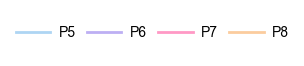

In [13]:
# Legend with P5,6,7,8
def export_p_legend_only_svg(df_app, save_path):
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from kin_tools.palettes import participant_color_map

    plt.rcParams["font.family"] = "Arial"

    participants = sorted(df_app["participant"].unique())
    part_colors = participant_color_map(participants)

    # Map original IDs (e.g., KIN3, KIN4, ...) to P5–P8 in order
    desired_labels = ["P5", "P6", "P7", "P8"]
    label_map = {
        p: lbl for p, lbl in zip(participants, desired_labels)
    }
    part_labels = [label_map[p] for p in participants]

    # Handles: participants (solid thin line, no marker)
    part_handles = [
        Line2D([0], [0],
               color=part_colors[p],
               lw=2,           # slightly thicker so the line is visible
               marker=None,
               label=part_labels[i])
        for i, p in enumerate(participants)
    ]

    # Single axis, legend centered, 1 x N horizontally
    fig, ax = plt.subplots(figsize=(3, 0.6))
    ax.axis("off")

    ax.legend(
        part_handles,
        part_labels,
        loc="center",
        ncol=len(participants),   # forces 1 row, all participants
        frameon=False,
        handlelength=2.5,
        handletextpad=0.6,
        columnspacing=0.8,
    )

    fig.patch.set_alpha(0.0)
    fig.savefig(save_path, format="svg", bbox_inches="tight")
    plt.show()


export_p_legend_only_svg(df_app, OUT_DIR / "fig5_legend_only.svg")


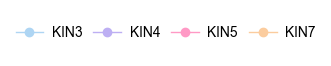

In [14]:
# Legend with KIN3,4,5,7
def export_legend_only_svg(df_app, save_path):
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from kin_tools.palettes import participant_color_map

    plt.rcParams['font.family'] = "Arial"

    participants = sorted(df_app["participant"].unique())
    part_colors = participant_color_map(participants)

    # Handles: participants (solid thin line + circle)
    part_handles = [
        Line2D([0], [0], color=part_colors[p], lw=1.0, marker="o", label=p)
        for p in participants
    ]
    part_labels = [p for p in participants]

    # Single axis, legend centered, 1 x N horizontally
    fig, ax = plt.subplots(figsize=(3, 0.6))
    ax.axis("off")

    ax.legend(
        part_handles,
        part_labels,
        loc="center",
        ncol=len(participants),     # forces 1 row, all participants
        frameon=False,
        handlelength=2,
        handletextpad=0.6,
        columnspacing=0.8,
    )

    fig.patch.set_alpha(0.0)
    fig.savefig(save_path, format="svg", bbox_inches="tight")
    plt.show()

export_legend_only_svg(df_app, OUT_DIR / "fig5_legend_only_kin.svg")


## Poster plot: TT application and removal times only

The bars show TT means, colored by phase. Participant trajectories are labeled P5–P8. Black lines and stars show the TT learning-model slopes and their significance.

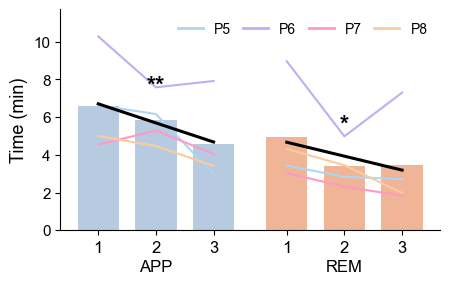

TT-only timing bar values:


,Phase,Session,TT bar mean (min),TT bar mean (mm:ss)
0,APP,1,6.62,6:37
1,APP,2,5.88,5:52
2,APP,3,4.59,4:36
3,REM,1,4.94,4:56
4,REM,2,3.40,3:24
5,REM,3,3.46,3:28


TT-only survey means:


,TT rating,Mean (1–10)
0,ease,8.62
1,stability,9.88
2,adhesion,9.96


In [19]:
def plot_tt_poster_times(df_app, df_rem, df_rate, save_stem=None):
    """Condensed poster panel with TT-only APP1–3 and REM1–3 timing."""
    app = df_app[df_app["method"] == "TT"].copy()
    rem = df_rem[df_rem["method"] == "TT"].copy()
    ratings = df_rate[df_rate["method"] == "TT"].copy()

    idxs = [1, 2, 3]
    app_x = np.array([0.0, 0.78, 1.56])
    rem_x = np.array([2.55, 3.33, 4.11])
    app_color = "#b6cbdf"
    rem_color = "#f0b497"

    participants = sorted(set(app["participant"]) & set(rem["participant"]))
    part_colors = participant_color_map(participants)
    participant_labels = {p: f"P{i + 5}" for i, p in enumerate(participants)}

    app_means_sec = np.array([
        app.loc[app["app_index"] == i, "time_sec"].mean() for i in idxs
    ], dtype=float)
    rem_means_sec = np.array([
        rem.loc[rem["rem_index"] == i, "time_sec"].mean() for i in idxs
    ], dtype=float)
    app_means_min = app_means_sec / 60.0
    rem_means_min = rem_means_sec / 60.0

    fig, ax = plt.subplots(figsize=(4.9, 3.25))
    ax.bar(app_x, app_means_min, color=app_color, alpha=1.0, width=0.56, zorder=1)
    ax.bar(rem_x, rem_means_min, color=rem_color, alpha=1.0, width=0.56, zorder=1)

    # P5–P8 trajectories within each phase.
    for p in participants:
        app_y = [
            app.loc[(app["participant"] == p) & (app["app_index"] == i), "time_sec"].iloc[0] / 60.0
            for i in idxs
        ]
        rem_y = [
            rem.loc[(rem["participant"] == p) & (rem["rem_index"] == i), "time_sec"].iloc[0] / 60.0
            for i in idxs
        ]
        ax.plot(app_x, app_y, color=part_colors[p], lw=1.5, zorder=3)
        ax.plot(rem_x, rem_y, color=part_colors[p], lw=1.5, zorder=3)

    # Preserve the Figure 5 TT learning-model slope lines and p-value stars.
    slope_app, p_app, fit_app = lme_learning_random_intercept_app(
        df_app, "TT", recode_app1_to_zero=True
    )
    slope_rem, p_rem, fit_rem = lme_learning_random_intercept_rem(
        df_rem, "TT", recode_rem1_to_zero=True
    )
    app_fit_min = np.array([
        float(fit_app.params["Intercept"]) + slope_app * (i - 1) for i in idxs
    ]) / 60.0
    rem_fit_min = np.array([
        float(fit_rem.params["Intercept"]) + slope_rem * (i - 1) for i in idxs
    ]) / 60.0
    ax.plot(app_x, app_fit_min, color="black", lw=2.2, zorder=4)
    ax.plot(rem_x, rem_fit_min, color="black", lw=2.2, zorder=4)

    raw_max_min = max(app["time_sec"].max(), rem["time_sec"].max()) / 60.0
    ytop = raw_max_min * 1.14
    star_offset = 0.025 * ytop
    ax.text(app_x.mean(), max(app_fit_min) + star_offset, p_to_stars(p_app),
            ha="center", va="bottom", fontsize=17, fontweight="bold")
    ax.text(rem_x.mean(), max(rem_fit_min) + star_offset, p_to_stars(p_rem),
            ha="center", va="bottom", fontsize=17, fontweight="bold")

    # Two-tier x labels: repeated session number, then phase.
    ax.set_xticks(np.r_[app_x, rem_x])
    ax.set_xticklabels(["1", "2", "3", "1", "2", "3"], fontsize=12)
    ax.text(app_x.mean(), -0.13, "APP", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=12)
    ax.text(rem_x.mean(), -0.13, "REM", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=12)
    ax.set_ylabel("Time (min)", fontsize=13)
    ax.set_ylim(0, ytop)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.tick_params(axis="y", labelsize=11)

    handles = [
        Line2D([0], [0], color=part_colors[p], lw=2, label=participant_labels[p])
        for p in participants
    ]
    ax.legend(handles=handles, frameon=False, ncol=len(handles), loc="upper right",
              handlelength=1.8, columnspacing=0.9, fontsize=10)

    fig.subplots_adjust(bottom=0.20)
    if save_stem is None:
        save_stem = OUT_DIR / "fig5_poster_tt_app_rem"
    save_stem = Path(save_stem)
    fig.savefig(save_stem.with_suffix(".svg"), format="svg", bbox_inches="tight")
    fig.savefig(save_stem.with_suffix(".png"), dpi=600, bbox_inches="tight")
    plt.show()

    # Exact values printed directly beneath the plot output.
    bar_values = pd.DataFrame({
        "Phase": ["APP"] * 3 + ["REM"] * 3,
        "Session": idxs + idxs,
        "TT bar mean (min)": np.r_[app_means_min, rem_means_min],
        "TT bar mean (mm:ss)": [sec_to_mmss(v) for v in np.r_[app_means_sec, rem_means_sec]],
    })
    bar_values["TT bar mean (min)"] = bar_values["TT bar mean (min)"].round(2)

    tt_rating_means = (
        ratings[ratings["metric"].isin(["ease", "stability", "adhesion"])]
        .groupby("metric", as_index=False)["rating"].mean()
        .set_index("metric").reindex(["ease", "stability", "adhesion"]).reset_index()
        .rename(columns={"metric": "TT rating", "rating": "Mean (1–10)"})
    )
    tt_rating_means["Mean (1–10)"] = tt_rating_means["Mean (1–10)"].round(2)

    print("TT-only timing bar values:")
    display(bar_values)
    print("TT-only survey means:")
    display(tt_rating_means)
    return fig, ax, bar_values, tt_rating_means


tt_poster_fig, tt_poster_ax, tt_bar_values, tt_rating_means = plot_tt_poster_times(
    df_app, df_rem, df_rate
)
